# Исследование стартапов

#### Цель 

Подготовить исследовательский анализ для будущей разработки модели бизнеса, чтобы финансовая компания могла войти на инвестиционный рынок с прицелом на покупку, развитие и последующую перепродажу перспективных стартапов.

#### Задачи:
- решить, по каким столбцам можно объединять данные из разных таблиц;
- понять, можно ли доверять данным о сотрудниках стартапов и их образовании;
- найти что означают покупки за 0 или за 1 доллар;
- определить, какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
- рассчитать и отобразить численные показатели и динамику.
В идеале - выявить показатели и признаки, которые указывают на повышенную вероятность успешной сделки по покупке компании


## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv

### 1.1. Вывод общей информации, исправление названия столбцов

- Загружаем все данные по проекту.
- Проверяем названия столбцов.
- Выводим информацию, которая необходима нам для принятия решений о предобработке, для каждого из датасетов.

In [1]:
!pip install missingno -q

In [2]:
pip install matplotlib-venn

     |████████████████████████████████| 40 kB 2.5 MB/s eta 0:00:011
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45388 sha256=73c0a858c12c3ec31e99835233f29f0bd6803bce33892ab0fae4eb01244b633c
  Stored in directory: /home/jovyan/.cache/pip/wheels/86/29/d8/0f3c5a37c967a34fb40aaabd414f92104d2ad5fb149c0114a1
Successfully built matplotlib-venn
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

In [4]:
# Загружаем данные
PATH = "https://code.s3.yandex.net/datasets/"

acquisition_df = pd.read_csv(PATH + 'acquisition.csv')
company_and_rounds_df = pd.read_csv(PATH + 'company_and_rounds.csv')
people_df = pd.read_csv(PATH + 'people.csv')
education_df = pd.read_csv(PATH + 'education.csv')
degrees_df = pd.read_csv(PATH + 'degrees.csv')
fund_df = pd.read_csv(PATH + 'fund.csv')
investment_df = pd.read_csv(PATH + 'investment.csv')

In [5]:
# Проверка названий столбцов для каждого датафрейма
print("acquisition_df columns:", acquisition_df.columns.tolist())
print("company_and_rounds_df columns:", company_and_rounds_df.columns.tolist())
print("people_df columns:", people_df.columns.tolist())
print("education_df columns:", education_df.columns.tolist())
print("degrees_df columns:", degrees_df.columns.tolist())
print("fund_df columns:", fund_df.columns.tolist())
print("investment_df columns:", investment_df.columns.tolist())

acquisition_df columns: ['id', 'acquiring_company_id', 'acquired_company_id', 'term_code', 'price_amount', 'acquired_at']
company_and_rounds_df columns: ['company  ID', 'name', 'category  code', 'status', 'founded  at', 'closed  at', 'domain', 'network  username', 'country  code', 'investment  rounds', 'funding  rounds', 'funding  total', 'milestones', 'funding  round  id', 'company  id', 'funded  at', 'funding  round  type', 'raised  amount', 'pre  money  valuation', 'participants', 'is  first  round', 'is  last  round']
people_df columns: ['id', 'first_name', 'last_name', 'company_id', 'network_username']
education_df columns: ['id', 'person_id', 'instituition', 'graduated_at']
degrees_df columns: ['id', 'object_id', 'degree_type', 'subject']
fund_df columns: ['id', 'name', 'founded_at', 'domain', 'network_username', 'country_code', 'investment_rounds', 'invested_companies', 'milestones']
investment_df columns: ['id', 'funding_round_id', 'company_id', 'fund_id']


In [6]:
# Заменяем пробелы на подчеркивания, убираем пробелы по краям, сохраняем регистр
import re

def clean_column_names(df):
    df.columns = [
        re.sub(r'\s+', '_', col.strip())  
        for col in df.columns
    ]
    return df

# Применяем к датафрейму, где замечнны проблемы
company_and_rounds_df = clean_column_names(company_and_rounds_df)

In [7]:
# Информация о acquisition_df
print("acquisition_df info:")
print(acquisition_df.info())

# Информация о company_and_rounds_df
print("\n\ncompany_and_rounds_df info:")
print(company_and_rounds_df.info())

# Информация о people_df
print("\n\npeople_df info:")
print(people_df.info())

# Информация о education_df
print("\n\neducation_df info:")
print(education_df.info())

# Информация о degrees_df
print("\n\ndegrees_df info:")
print(degrees_df.info())

# Информация о fund_df
print("\n\nfund_df info:")
print(fund_df.info())

# Информация о investment_df
print("\n\ninvestment_df info:")
print(investment_df.info())

acquisition_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB
None


company_and_rounds_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_ID           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status         

acquisition_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB
None

Пропуски в acquisition_df:
id                         0
acquiring_company_id       0
acquired_company_id        0
term_code               7576
price_amount               0
acquired_at               29
dtype: int64

Первые строки:
   id  acquiring_company_id  acquired_company_id term_code  price_amount  \
0   1                    11                   10       NaN      20000000   
1   7                    59      

<Figure size 720x288 with 0 Axes>

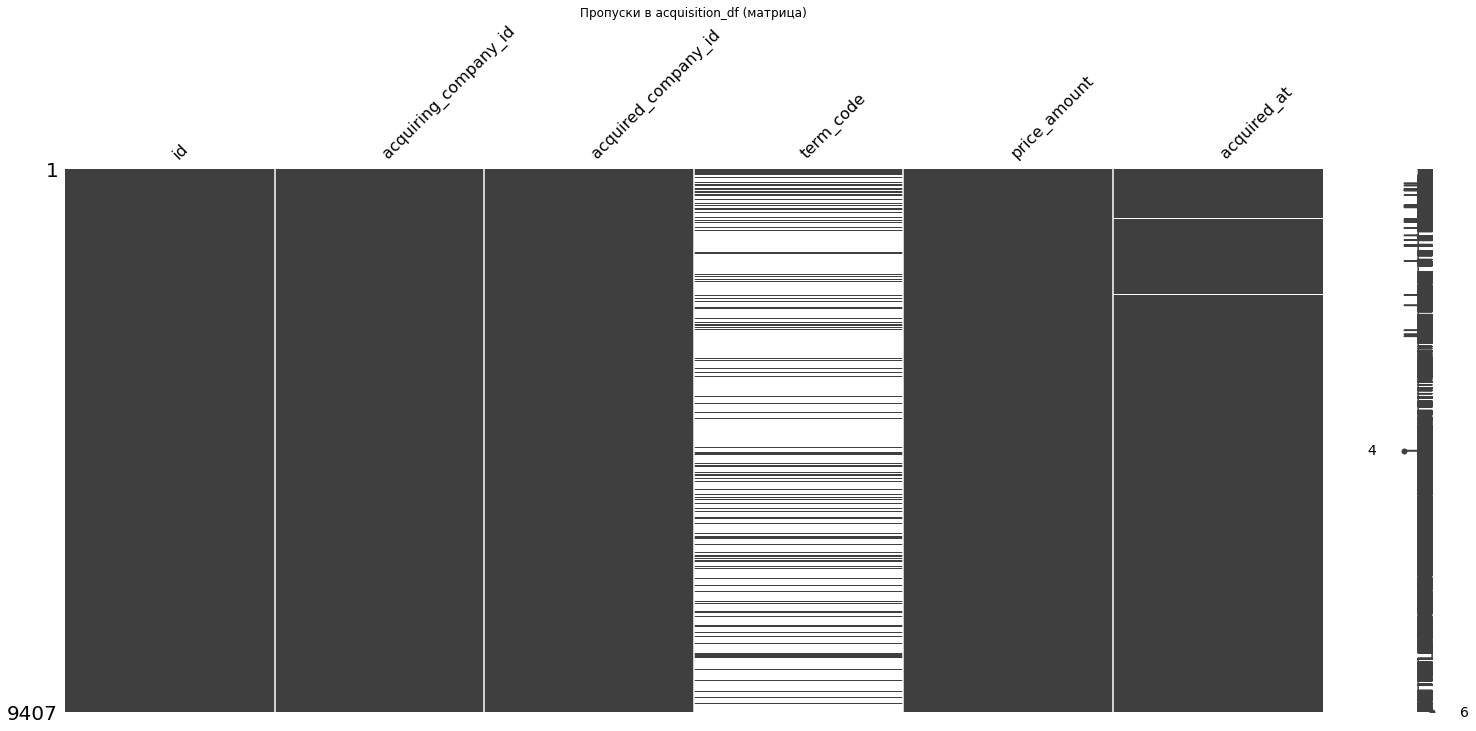

<Figure size 576x432 with 0 Axes>

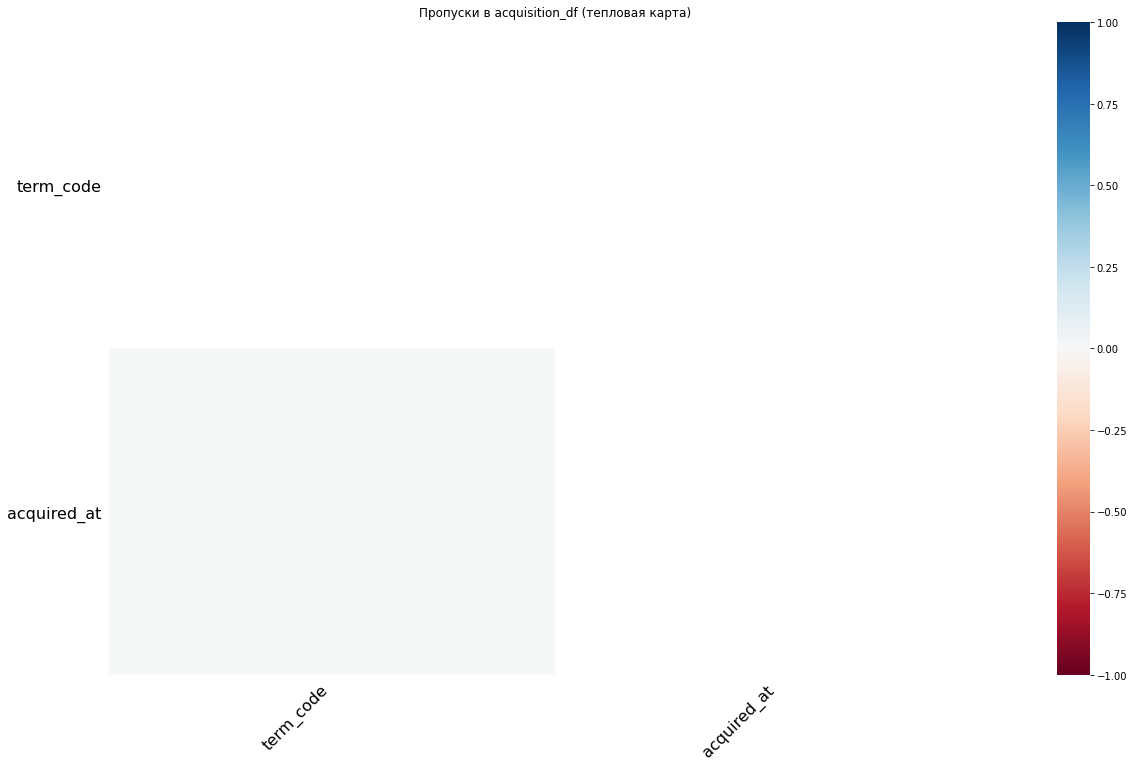

company_and_rounds_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_ID           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  company_id           52928 non-null   fl

<Figure size 720x288 with 0 Axes>

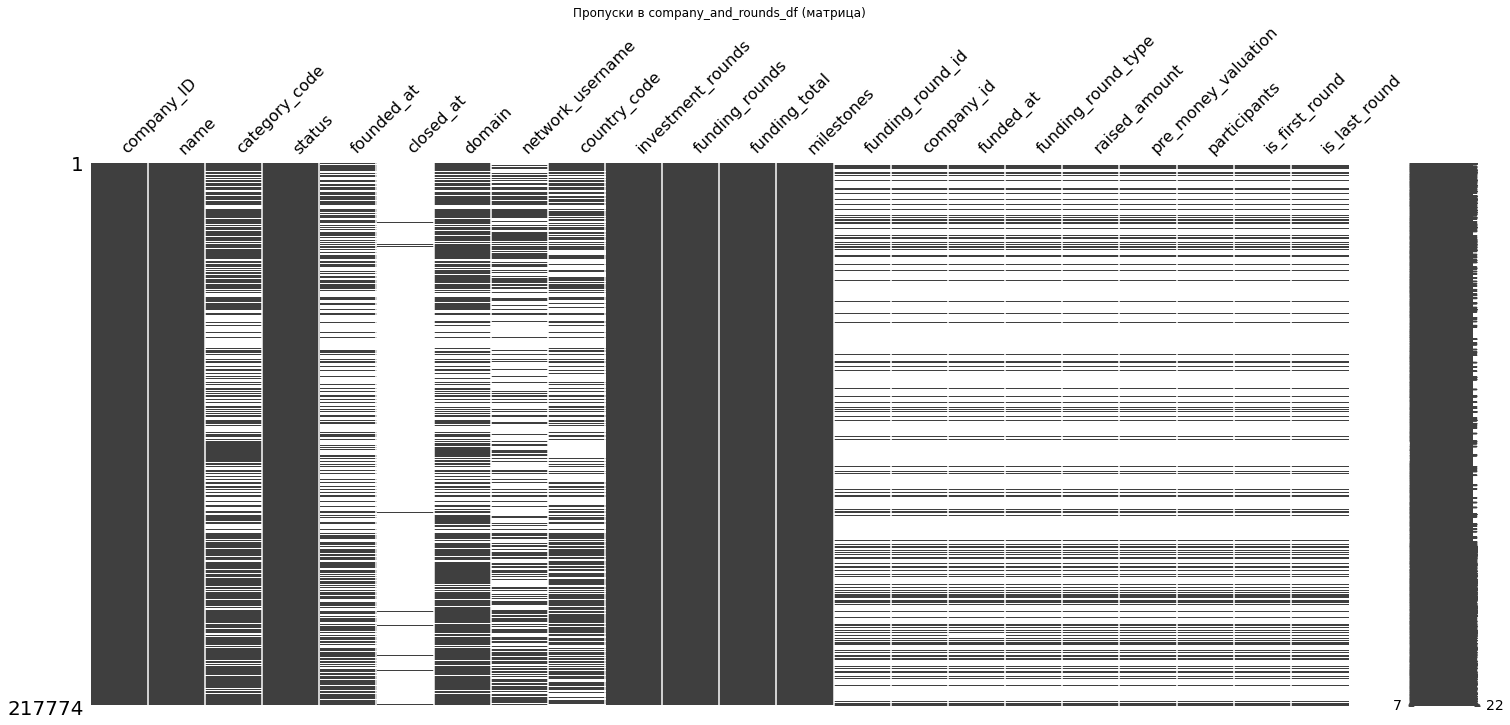

<Figure size 576x432 with 0 Axes>

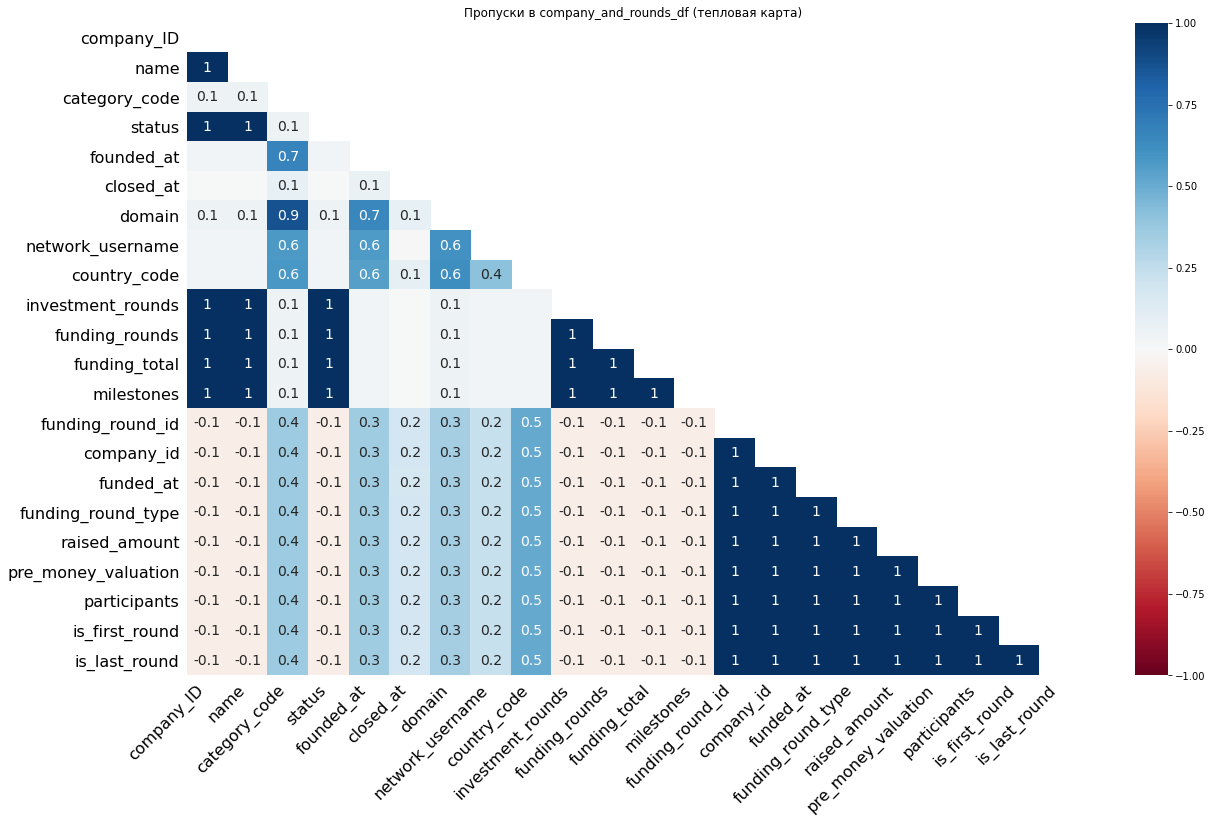

people_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB
None

Пропуски в people_df:
id                       0
first_name               5
last_name                1
company_id          192094
network_username    187842
dtype: int64

Первые строки:
       id  first_name    last_name  company_id network_username
0      10        Mark   Zuckerberg         5.0              NaN
1     100       Peter       Lester        27.0              NaN
2    1000  Dr. Steven  E. Saunders       292.0              NaN
3   10000        Neil       

<Figure size 720x288 with 0 Axes>

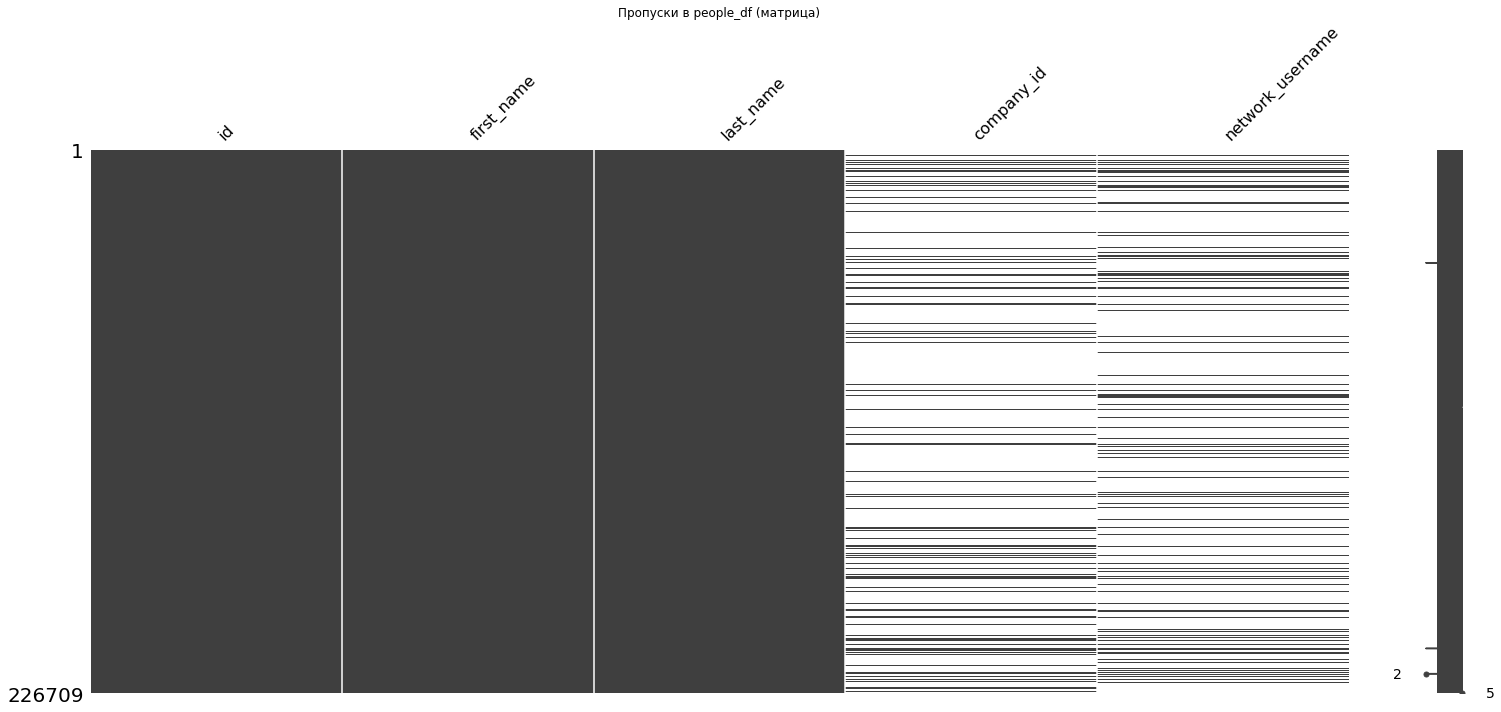

<Figure size 576x432 with 0 Axes>

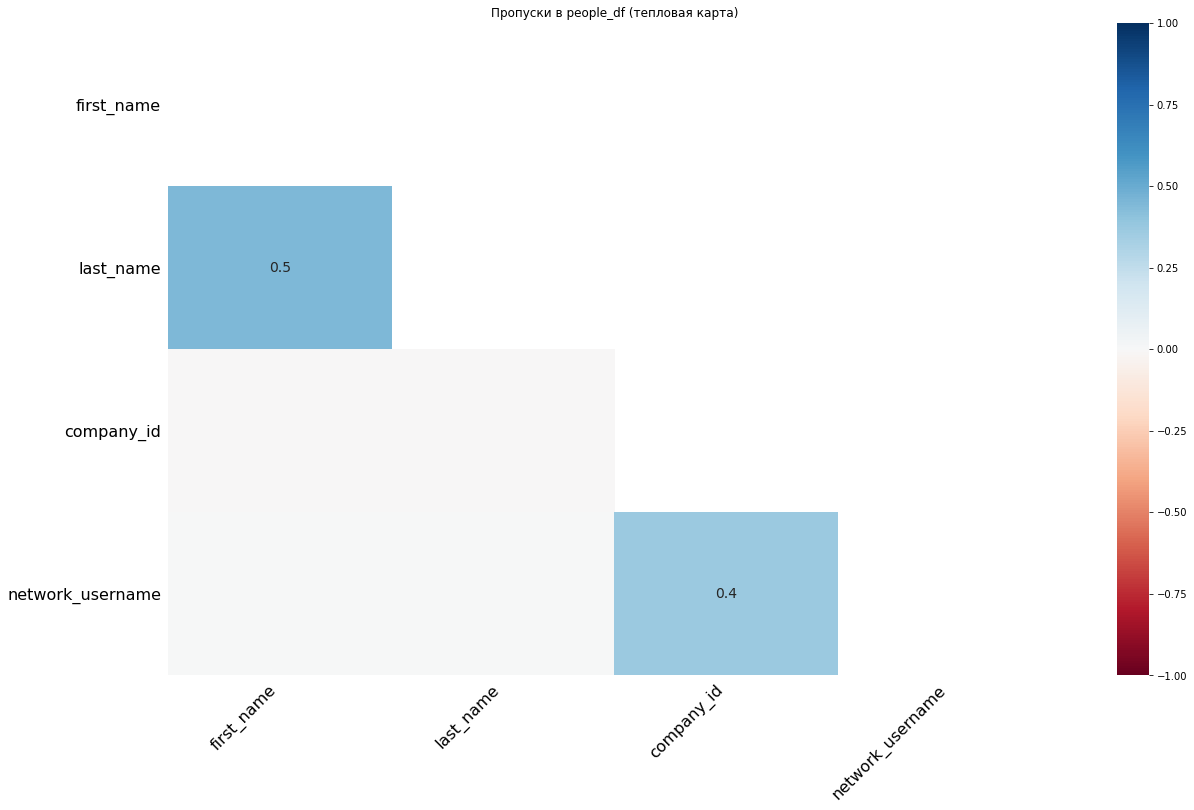

education_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB
None

Пропуски в education_df:
id                  0
person_id           0
instituition       55
graduated_at    51556
dtype: int64

Первые строки:
   id  person_id                      instituition graduated_at
0   1       6117                               NaN          NaN
1   2       6136  Washington University, St. Louis   1990-01-01
2   3       6136                 Boston University   1992-01-01
3   4       6005           University of Greenwich   2006-01-01
4   5       5832                   Rice University          NaN


<Figure size 720x288 with 0 Axes>

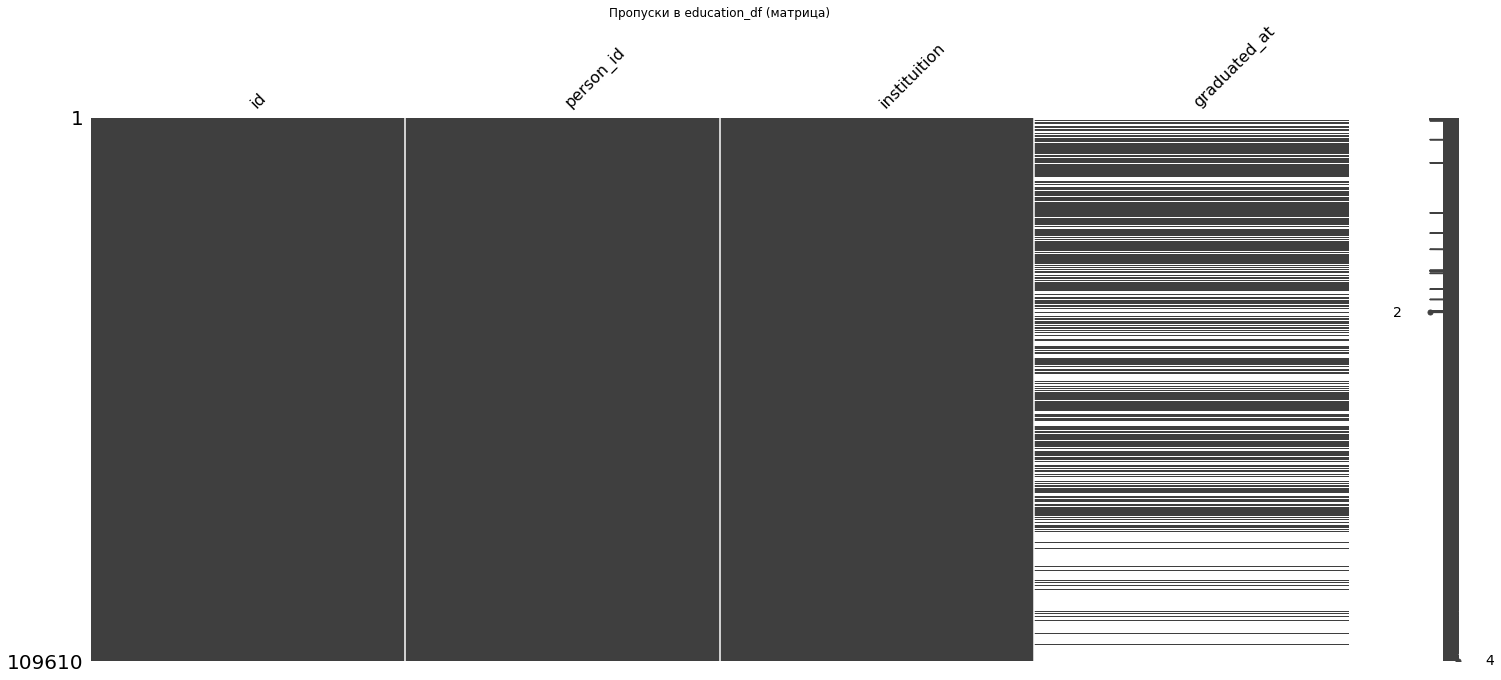

<Figure size 576x432 with 0 Axes>

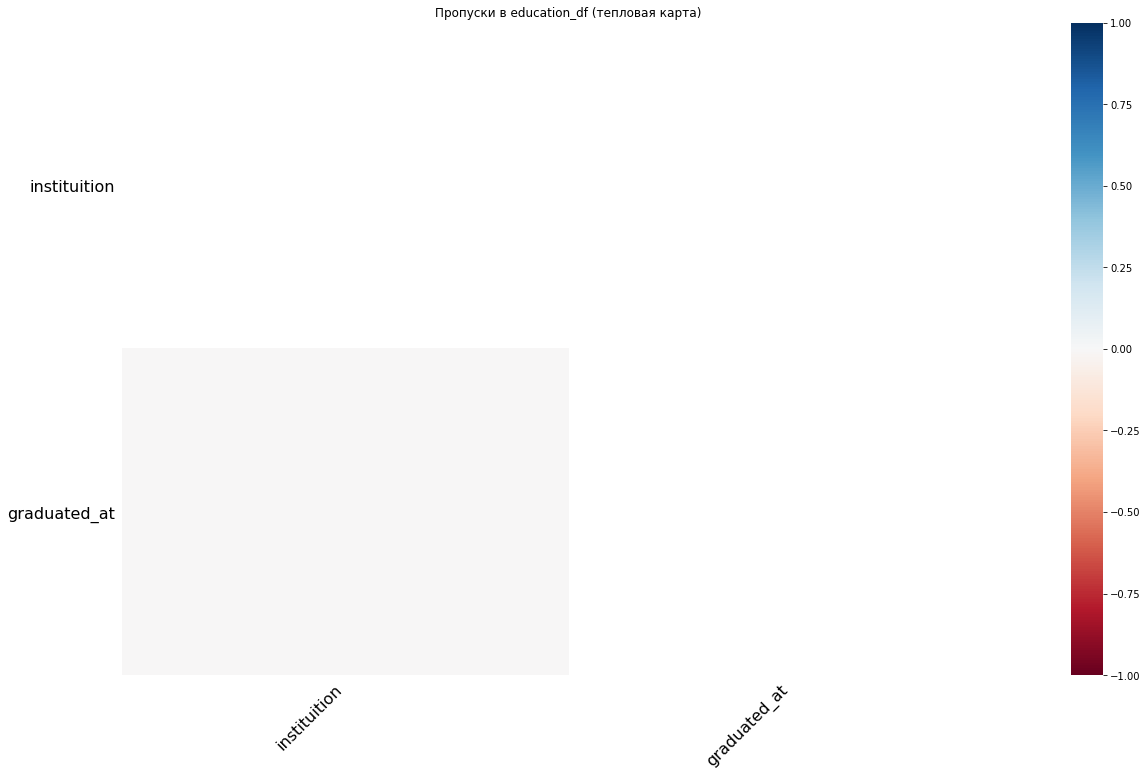

degrees_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB
None

Пропуски в degrees_df:
id                 0
object_id          0
degree_type    11218
subject        28312
dtype: int64

Первые строки:
   id object_id degree_type                       subject
0   1    p:6117         MBA                           NaN
1   2    p:6136          BA               English, French
2   3    p:6136          MS            Mass Communication
3   4    p:6005          MS           Internet Technology
4   5    p:5832         BCS  Computer Science, Psychology


<Figure size 720x288 with 0 Axes>

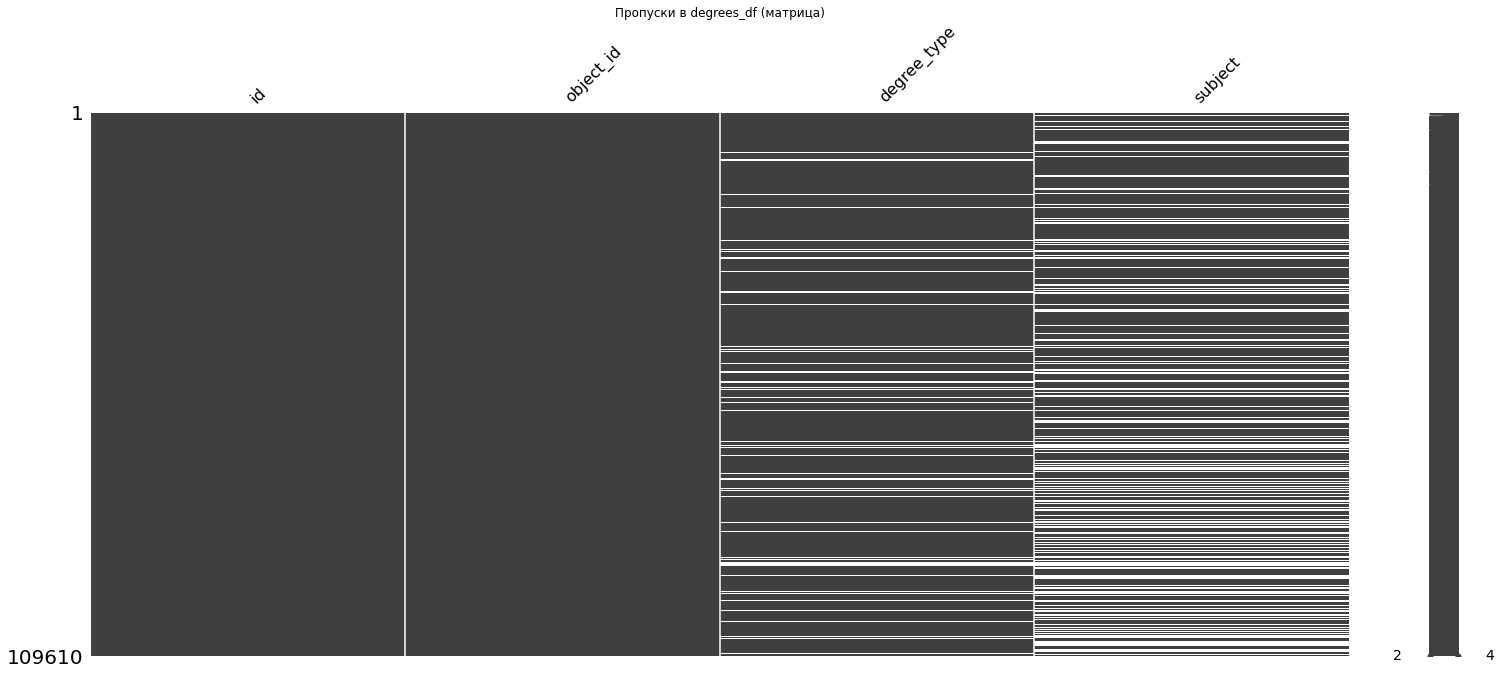

<Figure size 576x432 with 0 Axes>

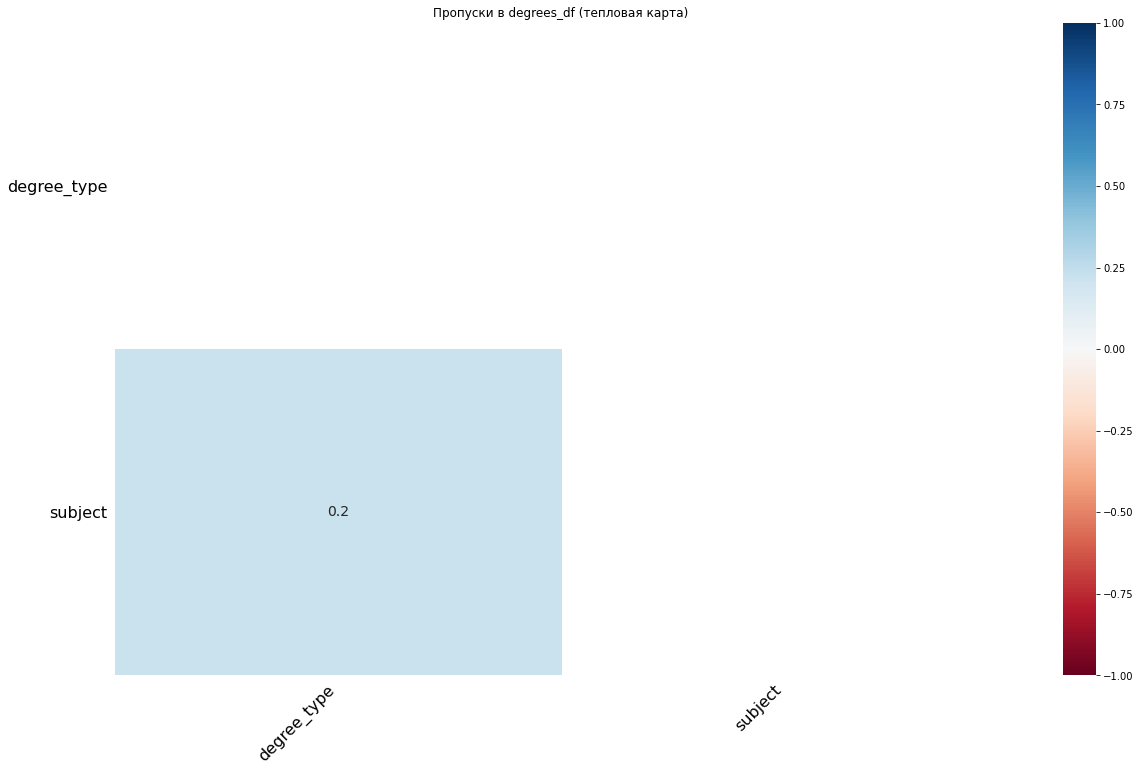

fund_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11650 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB
None

Пропуски в fund_df:
id                       0
name                     2
founded_at            7047
domain                4290
network_username      9503
country_code          4599
investment_rounds        0
invested_companies       0
milestones               0
dtype: int64

Первые строки:


<Figure size 720x288 with 0 Axes>

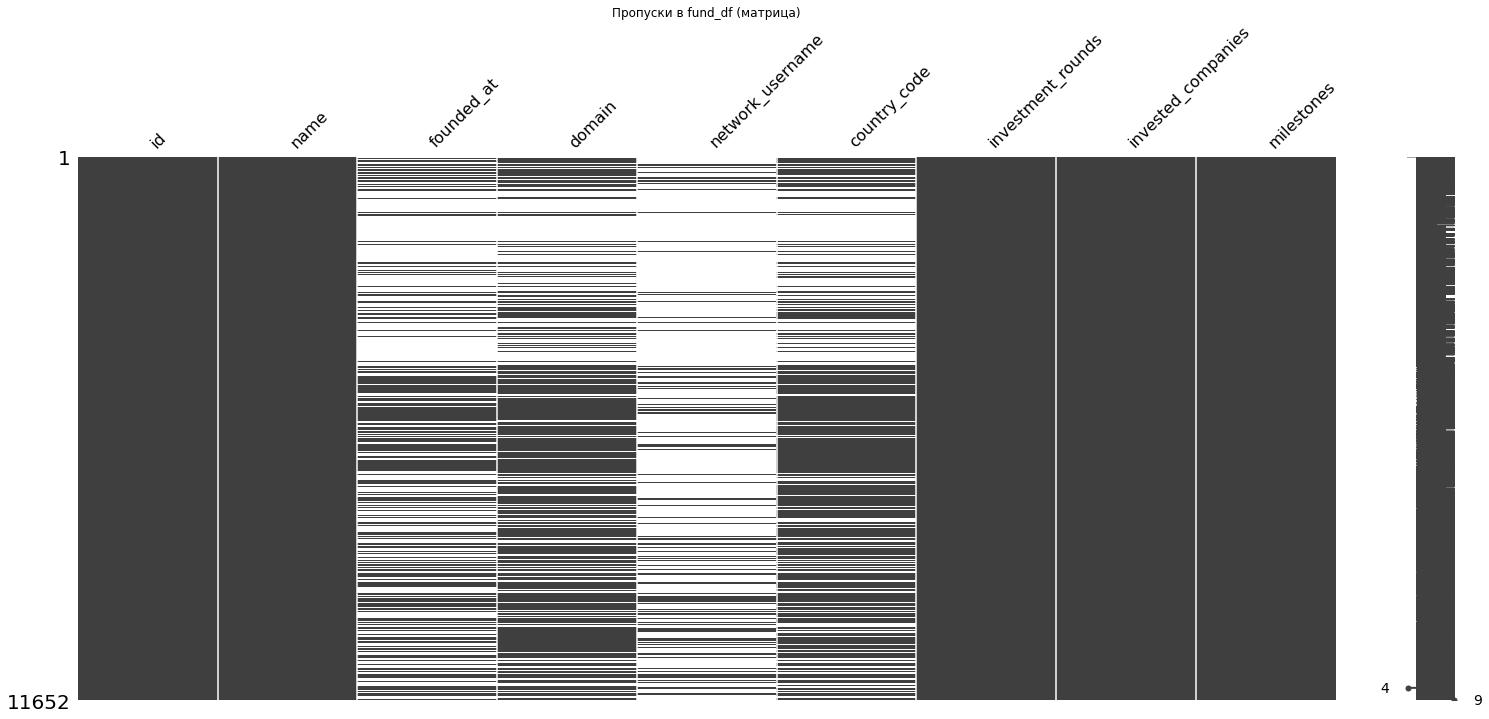

<Figure size 576x432 with 0 Axes>

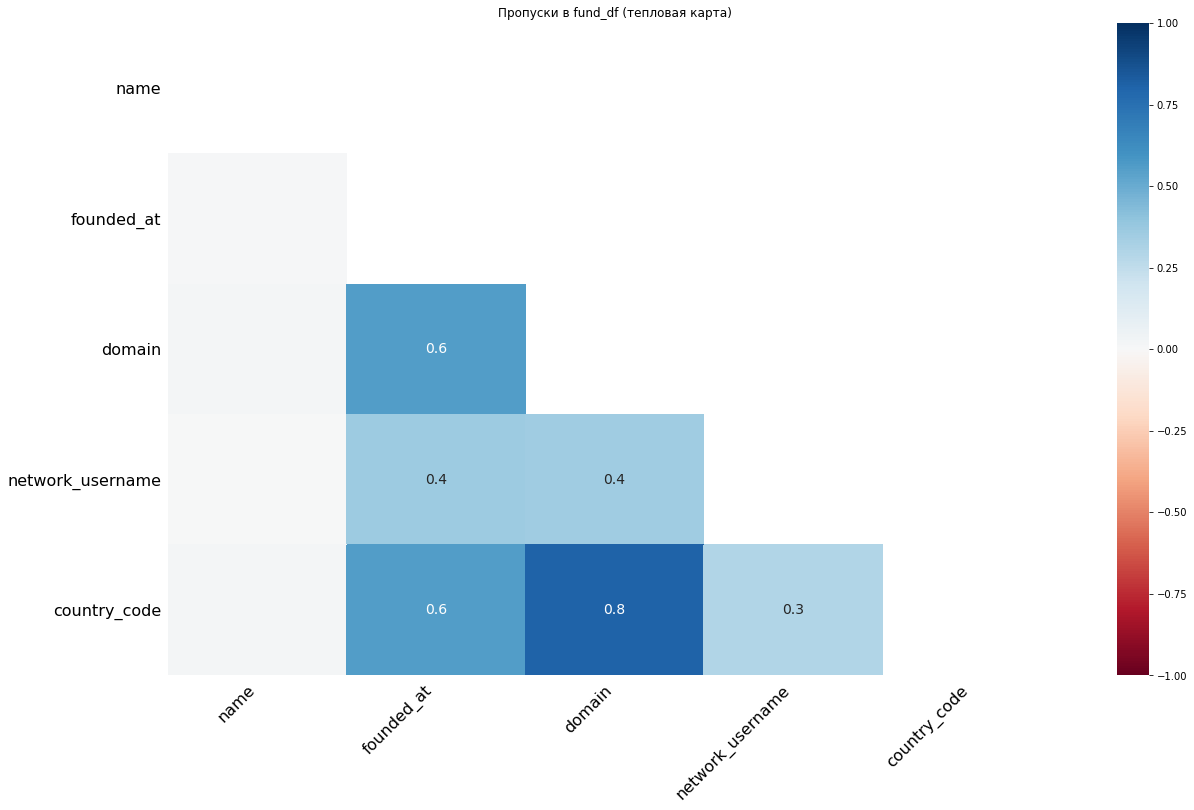

investment_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB
None

Пропуски в investment_df:
id                  0
funding_round_id    0
company_id          0
fund_id             0
dtype: int64

Первые строки:
   id  funding_round_id  company_id  fund_id
0   1                 1           4        1
1   2                 1           4        2
2   3                 3           5        4
3   4                 4           5        1
4   5                 4           5        5


<Figure size 720x288 with 0 Axes>

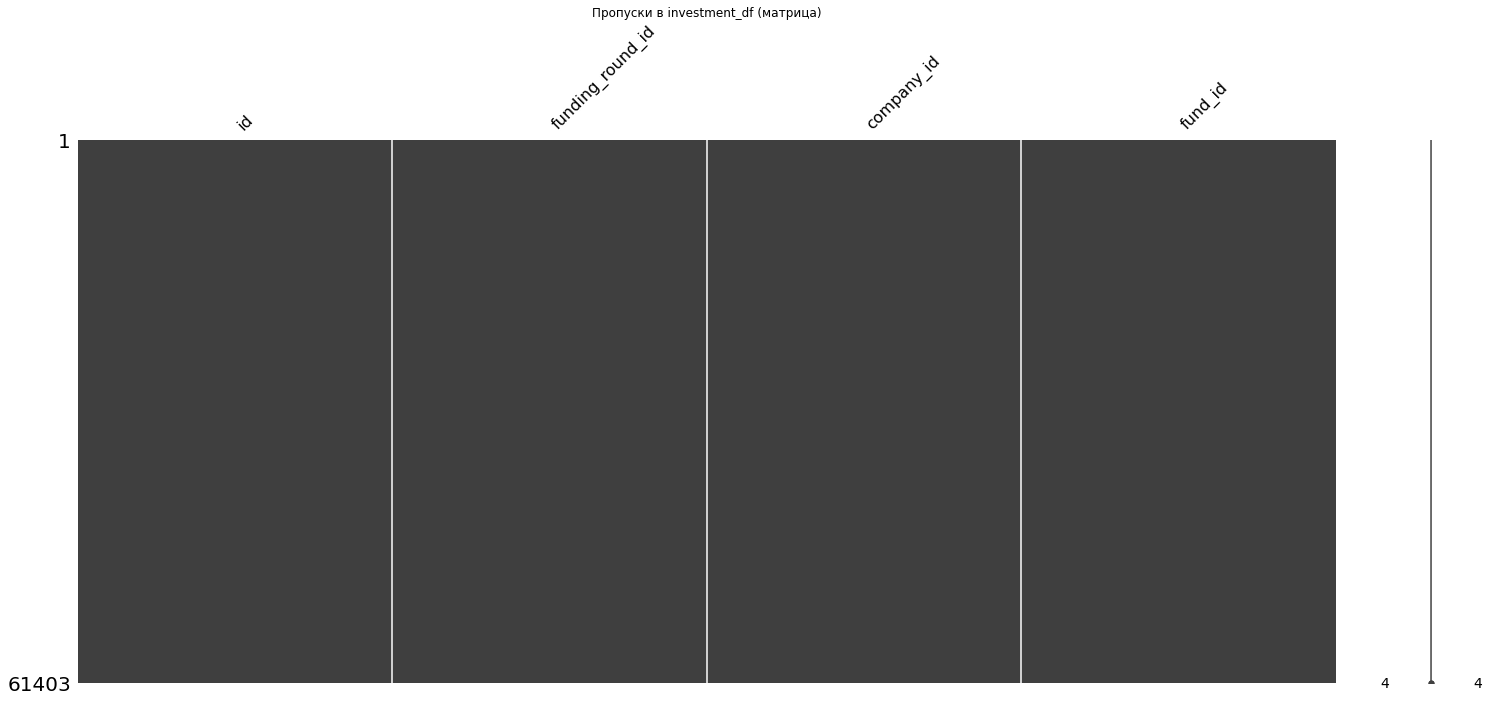

/opt/conda/lib/python3.9/site-packages/seaborn/matrix.py:301: UserWarning: Attempting to set identical left == right == 0 results in singular transformations; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/opt/conda/lib/python3.9/site-packages/seaborn/matrix.py:301: UserWarning: Attempting to set identical bottom == top == 0 results in singular transformations; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Figure size 576x432 with 0 Axes>

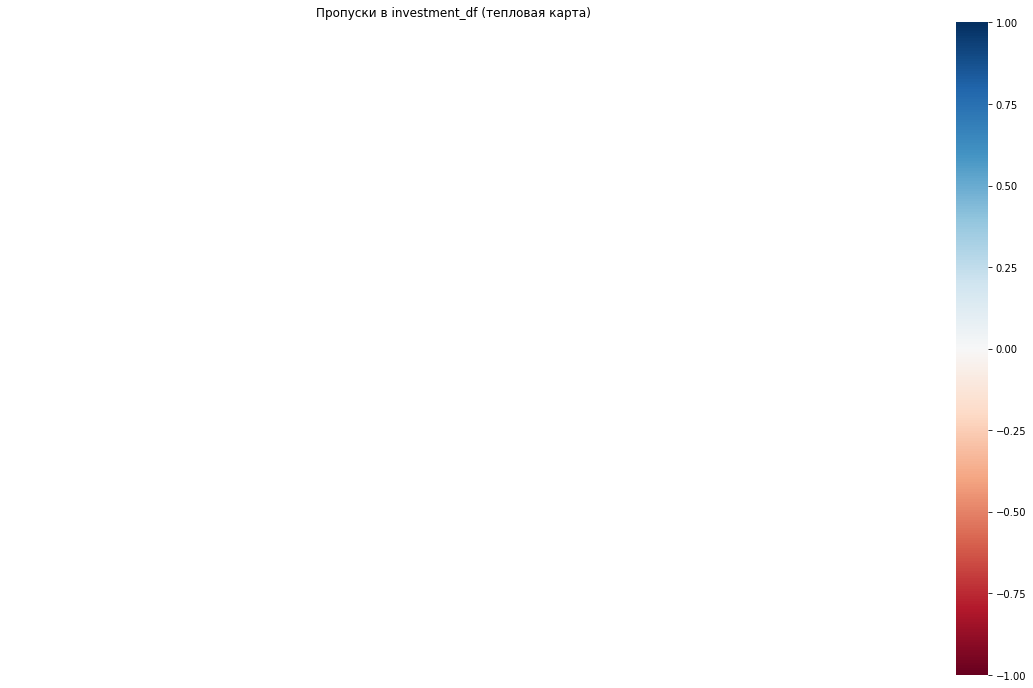

In [8]:
# Функция для вывода информации и пропусков
def analyze_dataframe(df, name):
    print(f"{name} info:")
    print(df.info())
    print(f"\nПропуски в {name}:")
    print(df.isnull().sum())
    print("\nПервые строки:")
    print(df.head())

    # Визуализация пропусков в виде матрицы
    plt.figure(figsize=(10, 4))
    msno.matrix(df)
    plt.title(f'Пропуски в {name} (матрица)')
    plt.show()

    # Визуализация пропусков в виде тепловой карты корреляции
    plt.figure(figsize=(8, 6))
    msno.heatmap(df)
    plt.title(f'Пропуски в {name} (тепловая карта)')
    plt.show()

# Анализируем все датафреймы
analyze_dataframe(acquisition_df, "acquisition_df")
analyze_dataframe(company_and_rounds_df, "company_and_rounds_df")
analyze_dataframe(people_df, "people_df")
analyze_dataframe(education_df, "education_df")
analyze_dataframe(degrees_df, "degrees_df")
analyze_dataframe(fund_df, "fund_df")
analyze_dataframe(investment_df, "investment_df")

#### Промежуточный вывод по имеющимся историческим данным:
- acquisition_df:
Данные о сделках приобретения компаний, 9407 записей. Основные поля — идентификаторы покупателя и приобретателя, дата приобретения, сумма сделки и термин (например, cash). Есть пропуски в дате (acquired_at) и в терминологии.

- company_and_rounds_df:
Информация о компаниях и раундах инвестиций, 217 774 записей. Включает название, категорию, статус, даты основания и закрытия, домен, страну, количество инвестиционных и фондовых раундов, а также детали раундов (тип, сумма, участие). Есть пропуски в ключевых датах и категориальных признаках.

- people_df:
Данные о людях, 226 709 записей. Есть сведения о имени, фамилии, связанной компании и сетевом имени пользователя. Значительное количество пропусков в company_id и network_username.

- education_df:
Образование людей, 109 610 записей. Включает учебное заведение и дату выпуска. Значительные пропуски в graduated_at и в учебных заведениях.

- degrees_df:
Информация о степенях, 109 610 записей. Включает тип степени и предмет. Есть пропуски в degree_type и subject.

- fund_df:
Данные о фондах, 11 652 записей. Включают название, дату основания, домен, страну и показатели активности. Есть пропуски в ключевых датах и в названиях.

- investment_df:
Связь инвестиций с раундами и фондами, 61 403 записи. Включает идентификаторы инвестиций, раундов, компаний и фондов. Без пропусков.

In [9]:
print("acquisition_df:")
display(acquisition_df.head())

print("\ncompany_and_rounds_df:")
display(company_and_rounds_df.head())

print("\npeople_df:")
display(people_df.head())

print("\neducation_df:")
display(education_df.head())

print("\ndegrees_df:")
display(degrees_df.head())

print("\nfund_df:")
display(fund_df.head())

print("\ninvestment_df:")
display(investment_df.head())

acquisition_df:


,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01



company_and_rounds_df:


,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



people_df:


...

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"



fund_df:


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1



investment_df:


,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


In [10]:
# Информация о acquisition_df
print("\nПропуски в acquisition_df:")
display(acquisition_df.isnull().sum())

# Информация о company_and_rounds_df
print("\nПропуски в company_and_rounds_df:")
display(company_and_rounds_df.isnull().sum())

# Информация о people_df
print("\nПропуски в people_df:")
display(people_df.isnull().sum())

# Информация о education_df
print("\nПропуски в education_df:")
display(education_df.isnull().sum())

# Информация о degrees_df
print("\nПропуски в degrees_df:")
display(degrees_df.isnull().sum())

# Информация о fund_df
print("\nПропуски в fund_df:")
display(fund_df.isnull().sum())

# Информация о investment_df
print("\nПропуски в investment_df:")
display(investment_df.isnull().sum())


Пропуски в acquisition_df:


id                         0
acquiring_company_id       0
acquired_company_id        0
term_code               7576
price_amount               0
acquired_at               29
dtype: int64


Пропуски в company_and_rounds_df:


company_ID                302
name                      302
category_code           73888
status                    302
founded_at             107818
closed_at              214325
domain                  70615
network_username       122240
country_code           109167
investment_rounds         302
funding_rounds            302
funding_total             302
milestones                302
funding_round_id       164846
company_id             164846
funded_at              165094
funding_round_type     164846
raised_amount          164846
pre_money_valuation    164846
participants           164846
is_first_round         164846
is_last_round          164846
dtype: int64


Пропуски в people_df:


...

id                 0
object_id          0
degree_type    11218
subject        28312
dtype: int64


Пропуски в fund_df:


id                       0
name                     2
founded_at            7047
domain                4290
network_username      9503
country_code          4599
investment_rounds        0
invested_companies       0
milestones               0
dtype: int64


Пропуски в investment_df:


id                  0
funding_round_id    0
company_id          0
fund_id             0
dtype: int64

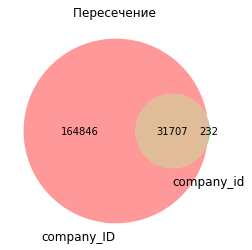

In [11]:
first_id = set(company_and_rounds_df['company_ID'].dropna().unique())
second_id = set(company_and_rounds_df['company_id'].dropna().unique())
# Строим диаграмму Венна
venn2([first_id, second_id], set_labels=('company_ID', 'company_id'))

# Отображаем график
plt.title("Пересечение ")
plt.show()

In [12]:
print(f"Совпадающих ID: {len(first_id & second_id)}")
print(f"Только в company_ID: {len(first_id - second_id)}")
print(f"Только в company_id: {len(second_id - first_id)}")

Совпадающих ID: 31707
Только в company_ID: 164846
Только в company_id: 232


31707 ID присутствуют в пересечении (пересекаются с другими группами).
- company_ID 164846 — уникален для этой группы (не пересекается с другими).
- company_id 232 — также уникален для своей группы (не пересекается с другими).


### 1.2. Смена типов и анализ пропусков

- Обработаем типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.
- Оцениваем полноту данных — делаем предварительный вывод, достаточно ли данных для решения задач проекта.

Столбцы, которые хранят значения даты и времени:
- acquisition_df: acquired_at
- company_and_rounds_df: founded_at, closed_at, funded_at
- education_df: graduated_at
- fund_df: founded_at

In [13]:
# Обработка дат в acquisition_df
acquisition_df['acquired_at'] = pd.to_datetime(acquisition_df['acquired_at'], errors='coerce')

# Обработка дат в company_and_rounds_df
company_and_rounds_df['founded_at'] = pd.to_datetime(company_and_rounds_df['founded_at'], errors='coerce')
company_and_rounds_df['closed_at'] = pd.to_datetime(company_and_rounds_df['closed_at'], errors='coerce')
company_and_rounds_df['funded_at'] = pd.to_datetime(company_and_rounds_df['funded_at'], errors='coerce')

# Обработка дат в education_df
education_df['graduated_at'] = pd.to_datetime(education_df['graduated_at'], errors='coerce')

# Обработка дат в fund_df
fund_df['founded_at'] = pd.to_datetime(fund_df['founded_at'], errors='coerce')

Предположения

Обработка пропусков:
В acquisition_df
— Для term_code и acquired_at: можно оставить как есть или заполнить значением 'Unknown' для term_code, а для дат — оставить NaT или заполнить средним/медианой, если релевантно.

В company_and_rounds_df
— Для категориальных полей (category  code, status, country  code) — можно заполнить Unknown или оставить как есть.
— Для дат (founded  at, closed  at) — привести к datetime, оставить NaN или заполнить средним/медианой.

В people_df
— В first_name, last_name — оставить как есть или исключить такие записи.
— В company_id — при необходимости можно заполнить или оставить NaN, в зависимости от целей анализа.

В education_df
— В instituition и graduated_at — либо оставить как есть, либо исключить строки с NaN, если они не нужны.

В degrees_df
— В degree_type и subject — можно заполнить 'Unknown' или исключить строки с NaN.

В fund_df
— В ключевых полях, таких как name, founded_at, domain, — заполнить 'Unknown' или оставить NaN в зависимости от задачи.


По предварительному осмотру делаю вывод, что данных достаточно для решения задач проекта.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам

Выполняем без объединения и дополнительной предобработки на основе датасета `company_and_rounds.csv`.

- Составляем сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:
    - типичный размер средств, выделяемый в рамках одного раунда;
    - общее количество раундов финансирования за этот год.
    
- Оставляем в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.
- На основе получившейся таблицы строим график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.


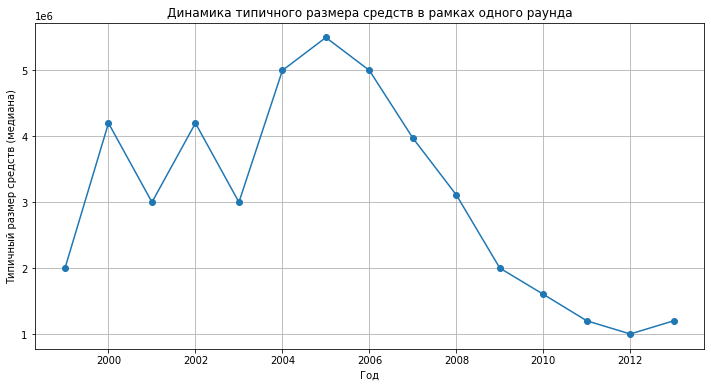

In [14]:
# Выделяем год
company_and_rounds_df['year'] = company_and_rounds_df['funded_at'].dt.year

# Создаем сводную таблицу по годам
grouped1 = company_and_rounds_df.groupby('year').agg(
    median_size=('raised_amount', 'median'),
    total_rounds=('raised_amount', 'count')
).reset_index()

# Оставляем только годы с более чем 50 раундами
filtered1 = grouped1[grouped1['total_rounds'] > 50]

# Строим график
plt.figure(figsize=(12,6))
plt.plot(filtered1['year'], filtered1['median_size'], marker='o')
plt.xlabel('Год')
plt.ylabel('Типичный размер средств (медиана)')
plt.title('Динамика типичного размера средств в рамках одного раунда')
plt.grid(True)
plt.show()

/tmp/ipykernel_161/1869172495.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered1['median_size_smooth'] = filtered1['median_size'].rolling(window=window_size).mean()
/tmp/ipykernel_161/1869172495.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered1['total_rounds_smooth'] = filtered1['total_rounds'].rolling(window=window_size).mean()


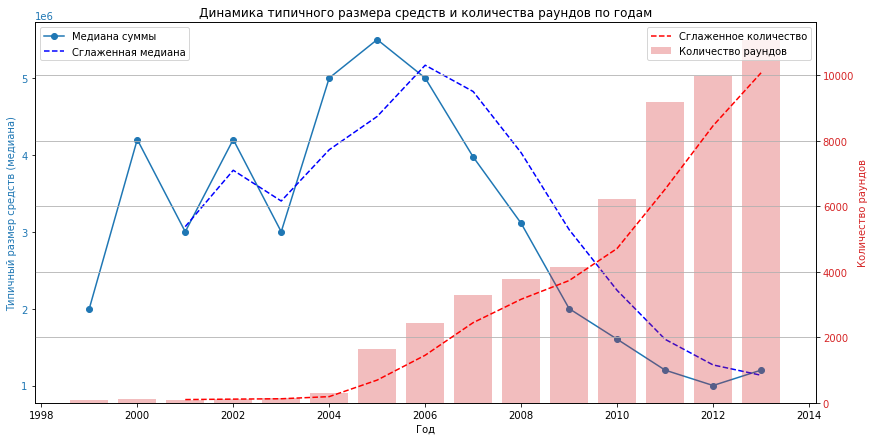

Максимальный типичный размер средств был в 2005.0 году: 5,500,000.0 долларов.

В 2013 году:
Количество раундов: 11072
Типичный размер средств: 1,200,000 долларов.

Обратите внимание, что в анализе видно, что в некоторые годы количество раундов растет, а средний размер раунда снижается, что может свидетельствовать о росте числа небольших раундов или о диверсификации финансирования.


In [15]:
# Добавление скользящей средней для сглаживания тренда
window_size = 3 
filtered1['median_size_smooth'] = filtered1['median_size'].rolling(window=window_size).mean()
filtered1['total_rounds_smooth'] = filtered1['total_rounds'].rolling(window=window_size).mean()

# График с двумя осями
fig, ax1 = plt.subplots(figsize=(14, 7))

color1 = 'tab:blue'
ax1.set_xlabel('Год')
ax1.set_ylabel('Типичный размер средств (медиана)', color=color1)
ax1.plot(filtered1['year'], filtered1['median_size'], marker='o', color=color1, label='Медиана суммы')
ax1.plot(filtered1['year'], filtered1['median_size_smooth'], linestyle='--', color='blue', label='Сглаженная медиана')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  # Вторая ось
color2 = 'tab:red'
ax2.set_ylabel('Количество раундов', color=color2)
ax2.bar(filtered1['year'], filtered1['total_rounds'], alpha=0.3, color=color2, label='Количество раундов')
ax2.plot(filtered1['year'], filtered1['total_rounds_smooth'], linestyle='--', color='red', label='Сглаженное количество')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.legend(loc='upper right')

plt.title('Динамика типичного размера средств и количества раундов по годам')
plt.grid(True)
plt.show()

# Ответы на вопросы:

# 1. Год с максимальным типичным размером
max_row = filtered1.loc[filtered1['median_size'].idxmax()]
print(f"Максимальный типичный размер средств был в {max_row['year']} году: {max_row['median_size']:,} долларов.")

# 2. Тенденции в 2013 году
data_2013 = filtered1[filtered1['year'] == 2013]
print(f"\nВ 2013 году:")
print(f"Количество раундов: {int(data_2013['total_rounds'].values[0])}")
print(f"Типичный размер средств: {data_2013['median_size'].values[0]:,.0f} долларов.")

# Гипотеза по трендам:
print("\nОбратите внимание, что в анализе видно, что в некоторые годы количество раундов растет, а средний размер раунда снижается, что может свидетельствовать о росте числа небольших раундов или о диверсификации финансирования.")

## Вывод:
- В течение анализируемого периода (после 2000 года) наблюдается существенное снижение типичного размера средств в рамках одного раунда, несмотря на рост количества раундов. Это свидетельствует о том, что стартапы в последние анализируемые годы чаще привлекают меньшие суммы, возможно, за счёт увеличения числа более мелких инвестиций и меньших раундов.

- Максимальный типичный размер средств был в 2005 году (~6 миллионов долларов). Это, скорее всего, пик "бумов" инвестиций, когда крупные раунды были более распространены.
- В 2013 году наблюдается очень большое число раундов (9,268), однако средний размер привлечённых средств в рамках одного раунда значительно снизился (1.2 миллиона долларов). Это может говорить о диверсификации финансирования: больше компаний привлекают меньшие суммы.
- Тенденция к увеличению количества раундов при снижении среднего размера говорит о том, что рынок становится более фрагментированным, и финансирование становится менее концентрированным в крупных раундах.

Такие изменения могут свидетельствовать о переходе к более "мелкому" финансированию новых стартапов, что может быть связано с более высокой конкуренцией, ростом числа новых участников рынка или изменением инвестиционной политики фондов.


### 2.2. Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оцениваем, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделяем все компании на несколько групп по количеству сотрудников и оцениваем среднюю долю сотрудников без информации об образовании в каждой из групп. 
- Оцениваем, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [16]:
# Проверим уникальные значения в person_id
print(education_df['person_id'].unique())

#Объединим
people_education = pd.merge(
    people_df,
    education_df,
    how='left',
    left_on='id',
    right_on='person_id',
    suffixes=('_people', '_education')
)
# Результат
print(people_education.head())


[  6117   6136   6005 ... 268589 268527 268528]
   id_people  first_name    last_name  company_id network_username  \
0         10        Mark   Zuckerberg         5.0              NaN   
1        100       Peter       Lester        27.0              NaN   
2       1000  Dr. Steven  E. Saunders       292.0              NaN   
3      10000        Neil        Capel      2526.0              NaN   
4     100000         Sue       Pilsch         NaN              NaN   

   id_education  person_id        instituition graduated_at  
0        2415.0       10.0  Harvard University          NaT  
1           NaN        NaN                 NaN          NaT  
2           NaN        NaN                 NaN          NaT  
3           NaN        NaN                 NaN          NaT  
4           NaN        NaN                 NaN          NaT  


In [17]:
# Посмотрим на сотрудников с company_id == 1
company_1 = people_education[people_education['company_id'] == 1]

# Проверим, есть ли дубликаты по имени и другим признакам
print(company_1[['first_name', 'id_people', 'id_education']])



       first_name  id_people  id_education
4393         Alex     104800           NaN
191139      Kevin          3         706.0
191140      Kevin          3         707.0


In [18]:
# Убрать дубликаты по уникальному идентификатору человека?
people_education_unique = people_education.drop_duplicates(subset=['id_people'])

# Результат
print(people_education_unique.head())

   id_people  first_name    last_name  company_id network_username  \
0         10        Mark   Zuckerberg         5.0              NaN   
1        100       Peter       Lester        27.0              NaN   
2       1000  Dr. Steven  E. Saunders       292.0              NaN   
3      10000        Neil        Capel      2526.0              NaN   
4     100000         Sue       Pilsch         NaN              NaN   

   id_education  person_id        instituition graduated_at  
0        2415.0       10.0  Harvard University          NaT  
1           NaN        NaN                 NaN          NaT  
2           NaN        NaN                 NaN          NaT  
3           NaN        NaN                 NaN          NaT  
4           NaN        NaN                 NaN          NaT  


Распределение количества сотрудников в компаниях (топ-20):
1     14150
2      4735
3      1857
4       831
5       447
6       259
7       161
8       115
9        86
10       51
11       52
12       25
13       26
14       12
15       14
16       12
17        8
18       16
19       10
20        9
Name: total_employees, dtype: int64
Средняя доля сотрудников без данных об образовании по группам размера компаний:
  size_group  share_without_education
0          1                 0.592862
1          2                 0.227350
2          3                 0.228325
3        4-5                 0.276252
4       6-10                 0.312232
5      11-25                 0.306520
6        26+                 0.204581


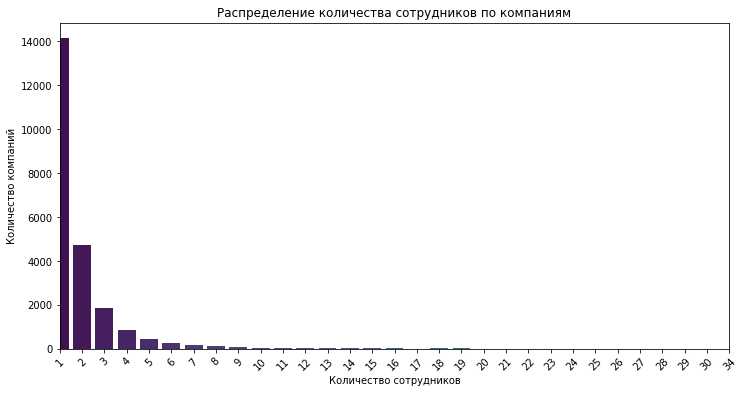

In [19]:
# Расчет общего количества сотрудников и сотрудников с образованием
company_stats = people_education.groupby('company_id').agg(
    total_employees=('id_people', 'count'), # Исправлено на id_people, так как id_x был до переименования
    employees_with_education=('instituition', lambda x: x.notna().sum())
).reset_index()

# Расчет количества сотрудников без данных об образовании и их доли
company_stats['employees_without_education'] = company_stats['total_employees'] - company_stats['employees_with_education']
company_stats['share_without_education'] = company_stats['employees_without_education'] / company_stats['total_employees']


print("Распределение количества сотрудников в компаниях (топ-20):")
print(company_stats['total_employees'].value_counts().sort_index().head(20)) # Посмотрим на самые частые размеры

# Используем предложенные диапазоны для группировки по размерам компаний
bins = [0, 1, 2, 3, 5, 10, 25, np.inf]
labels = ['1', '2', '3', '4-5', '6-10', '11-25', '26+']
company_stats['size_group'] = pd.cut(company_stats['total_employees'], bins=bins, labels=labels, right=True)

# Расчет средней доли сотрудников без образования по группам
grouped = company_stats.groupby('size_group')['share_without_education'].mean().reset_index()

print("Средняя доля сотрудников без данных об образовании по группам размера компаний:")
print(grouped)

# Визуализация

plt.figure(figsize=(12, 6))
sns.countplot(data=company_stats, x='total_employees', palette='viridis')
plt.title('Распределение количества сотрудников по компаниям')
plt.xlabel('Количество сотрудников')
plt.ylabel('Количество компаний')
plt.xticks(rotation=45)
plt.xlim(0, 30) # Ограничимся компаниями до 30 сотрудников для наглядности, если есть очень крупные
plt.show()

Обоснование. Группы выбраны так, чтобы отражать реальные масштабы компаний и обеспечить достаточную статистическую выборку в каждой категории:
- В компаниях с одним сотрудником данных об образовании отсутствуют, возможно, из-за недостатка данных или малых размеров.
- В небольших компаниях (2–3 сотрудника) доля сотрудников без информации об образовании значительно выше (около 59%), что может указывать на меньшую аккуратность или меньшую важность этого параметра в маленьких фирмах.
- В группах среднего размера (4–25 сотрудников) доля сотрудников без данных снижается, достигая примерно 22–32%.
- В крупных компаниях (более 26 сотрудников) доля без данных снова снижается и составляет около 20%, что может свидетельствовать о более систематическом сборе информации.

Общий вывод: Меньшие компании характеризуются большей пропорцией отсутствия данных об образовании сотрудников, что может отражать различия в управлении данными или в структуре кадров

Присоединять к этим таблицам таблицу degrees.csv - не нужно

### 2.3. Объединять или не объединять — вот в чём вопрос

Некоторые названия столбцов встречаются в датасетах чаще других. В результате предварительной проверки датасетов было выяснено, что столбец `company_id` подходит для объединения данных.


In [20]:
# Для каждого датасета, где есть столбец network_username, считаем число уникальных значений и общее число строк
datasets = {
    'people_df': people_df,
    'company_and_rounds_df': company_and_rounds_df,
    'fund_df': fund_df,
}

for name, df in datasets.items():
    if 'network_username' in df.columns:
        total_rows = len(df)
        unique_usernames = df['network_username'].nunique(dropna=True)
        duplicate_count = total_rows - unique_usernames
        print(f"{name}:")
        print(f"  Всего записей: {total_rows}")
        print(f"  Уникальных network_username: {unique_usernames}")
        print(f"  Дублирующихся (повторяющихся): {duplicate_count}")
        print(f"  Процент дублирующихся: {duplicate_count / total_rows:.2%}\n")

people_df:
  Всего записей: 226709
  Уникальных network_username: 38421
  Дублирующихся (повторяющихся): 188288
  Процент дублирующихся: 83.05%

company_and_rounds_df:
  Всего записей: 217774
  Уникальных network_username: 79571
  Дублирующихся (повторяющихся): 138203
  Процент дублирующихся: 63.46%

fund_df:
  Всего записей: 11652
  Уникальных network_username: 2098
  Дублирующихся (повторяющихся): 9554
  Процент дублирующихся: 81.99%



Значения network_username не являются уникальными в этих датасетах.
Высокий уровень дубликатов (> 80%) говорит о том, что один и тот же network_username может встречаться у множества различных записей.
Поэтому использовать network_username в качестве ключа для объединения данных не следует, т.к. он не обеспечит уникальность и может привести к некорректным соединениям или дублированию данных.

Для объединения данных лучше всё же использовать столбец с более высокой уникальностью, например company_id.

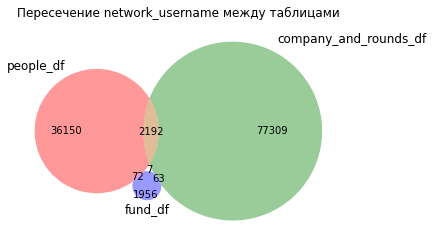

In [21]:
# Получаем множества username
people_usernames = set(people_df['network_username'].dropna().unique())
company_usernames = set(company_and_rounds_df['network_username'].dropna().unique())
fund_usernames = set(fund_df['network_username'].dropna().unique())

# Строим диаграмму Венна
venn3([people_usernames, company_usernames, fund_usernames], 
      set_labels=('people_df', 'company_and_rounds_df', 'fund_df'))

plt.title("Пересечение network_username между таблицами")
plt.show()

Так как пересения минимальные -  в одном случае речь идёт о никах компании, а в другом о никах людей. Совпадение названия столбцов разных таблиц - формальное.


### 2.4. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.


По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.


In [22]:
# 1-вая таблица: Выбираем только строки, где есть данные о компании
company_columns = [
    'company_ID', 'name', 'category_code', 'status', 'founded_at',
    'closed_at', 'domain', 'network_username', 'country_code',
    'investment_rounds', 'funding_rounds', 'funding_total', 'milestones'
]
companies_df = company_and_rounds_df[company_columns].dropna(subset=['company_ID'])

# Удаляем дубликаты компаний
companies_df = companies_df.drop_duplicates(subset='company_ID')

print("Таблица компаний:")
print(f"Форма: {companies_df.shape}")
display(companies_df.head())

# 2-ая таблица: Выбираем только строки, где есть данные о раундах

round_columns = [
    'company_id', 'funding_round_id', 'funded_at', 'funding_round_type',
    'raised_amount', 'pre_money_valuation', 'participants',
    'is_first_round', 'is_last_round'
]

# Удаляем дубликаты раундов
rounds_df = (
    company_and_rounds_df[round_columns]
    .dropna(subset=['company_id', 'raised_amount'])
)

print("Таблица раундов:")
print(f"Форма: {rounds_df.shape}")
display(rounds_df.head())

print(f"Уникальных компаний: {companies_df['company_ID'].nunique()}")
print(f"Уникальных раундов: {rounds_df['funding_round_id'].nunique()}")

Таблица компаний:
Форма: (196553, 13)


,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0
5,10000.0,MYWEBBO,network_hosting,operating,2008-07-26,NaT,mywebbo.com,NaN,NaN,0.0,0.0,0.0,0.0
6,10001.0,THE Movie Streamer,games_video,operating,2008-07-26,NaT,themoviestreamer.com,NaN,NaN,0.0,0.0,0.0,0.0


Таблица раундов:
Форма: (52928, 9)


,company_id,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,888.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,889.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,2312.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
15,1001.0,1644.0,2008-02-26,series-a,5000000.0,0.0,3.0,1.0,1.0
20,10014.0,6682.0,2008-09-01,angel,0.0,0.0,1.0,1.0,1.0


Уникальных компаний: 196553
Уникальных раундов: 52928



## Шаг 3. Исследовательский анализ объединённых таблиц




### 3.1. Объединение данных

Объединяем данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы берем данные из обработанного датасета `company_and_rounds.csv` —  только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. 


In [23]:
filtred_df = companies_df[(companies_df['funding_rounds'] >0 )|(companies_df['investment_rounds']>0)|(companies_df['status']=='acquired')]
filtred_df.shape[0]

40747

In [24]:
display(filtred_df.head())
filtred_df.info()

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0
20,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,1.0,0.0,4.0


<class 'pandas.core.frame.DataFrame'>
Int64Index: 40747 entries, 0 to 217469
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_ID         40747 non-null  float64       
 1   name               40747 non-null  object        
 2   category_code      35315 non-null  object        
 3   status             40747 non-null  object        
 4   founded_at         27807 non-null  datetime64[ns]
 5   closed_at          2128 non-null   datetime64[ns]
 6   domain             35754 non-null  object        
 7   network_username   20850 non-null  object        
 8   country_code       34742 non-null  object        
 9   investment_rounds  40747 non-null  float64       
 10  funding_rounds     40747 non-null  float64       
 11  funding_total      40747 non-null  float64       
 12  milestones         40747 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(6)
memory usage: 4.

In [25]:
#Создаем DataFrame для топ компаний
top_companies = filtred_df.sort_values(by='funding_total', ascending=False).head(10)

print("Топ 10 компаний по сумме инвестиций:")
print(top_companies[['company_ID', 'name', 'category_code', 'funding_total', 'investment_rounds']])

# 4. Анализ по категориям
category_stats = filtred_df.groupby('category_code').agg({
    'funding_total': 'sum',
    'company_ID': 'count'
}).rename(columns={'company_ID': 'company_count'})

top_categories = category_stats.sort_values(by='funding_total', ascending=False).head(10)

print("\nТоп 10 категорий по сумме инвестиций:")
print(top_categories)

Топ 10 компаний по сумме инвестиций:
        company_ID                          name  category_code  \
5517       13219.0                     Clearwire         mobile   
175686      4843.0  Verizon Communications, Inc.         mobile   
106151    242735.0                     sigmacare         health   
217286         5.0                     Socialnet         social   
193712     64365.0                    Carestream        biotech   
88129      22568.0                      Solyndra  manufacturing   
188342      5951.0             Fisker Automotive     automotive   
165194     39799.0                  O3b Networks     enterprise   
110613     24693.0               Terra-Gen Power      cleantech   
217297        12.0                       Network         social   

        funding_total  investment_rounds  
5517     5.700000e+09                0.0  
175686   3.985050e+09                3.0  
106151   2.600000e+09                0.0  
217286   2.425700e+09                3.0  
193712   2


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.


count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64


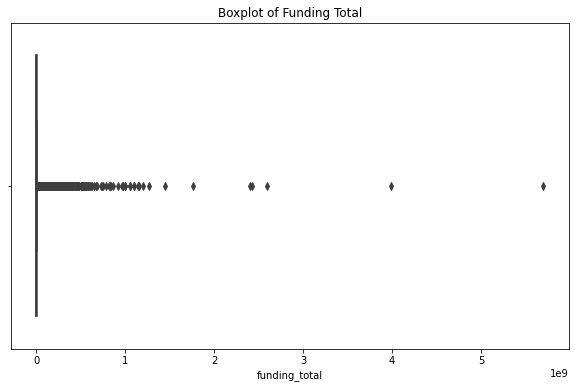

Типичный диапазон финансирования: от -8475975.00 до 14126625.00
Количество выбросов: 5858


In [26]:
# Обзор статистики
desc = filtred_df['funding_total'].describe()
print(desc)

# Визуализация
plt.figure(figsize=(10, 6))
sns.boxplot(x=filtred_df['funding_total'])
plt.title('Boxplot of Funding Total')
plt.show()

# Расчет границ для определения выбросов
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Типичный диапазон финансирования: от {lower_bound:.2f} до {upper_bound:.2f}")

# Выбросы:
outliers = filtred_df[(filtred_df['funding_total'] < lower_bound) | (filtred_df['funding_total'] > upper_bound)]
print(f"Количество выбросов: {len(outliers)}")

- Распределение финансирования сильно скошено вправо (положительно), что говорит о наличии большого количества компаний с небольшими или нулевыми значениями финансирования и относительно небольшим числом компаний с очень большими суммами финансирования.
- Среднее значение (около 10 миллионов) значительно превышает медиану (около 600 тысяч), что свидетельствует о наличии выбросов — компаний с очень крупными суммами финансирования, которые и тянут среднее вверх.
- Границы типичного диапазона (от около 0 до примерно 56 миллионов) показывают, что большинство компаний имеют финансирование в пределах этого диапазона. В то же время, максимальное значение — около 5,7 миллиардов, что является явным выбросом.
- На графике видно, что большинство данных сосредоточено в узком диапазоне, а "усы" и отдельные точки за пределами — это выбросы, то есть компании с аномально высоким финансированием.

Вывод:
Большая часть компаний получает относительно небольшие суммы финансирования, а очень крупные суммы — редкость и могут существенно искажать статистические показатели. Для анализа типичных значений лучше ориентироваться на медиану и межквартильный размах, а выбросы стоит учитывать отдельно или при необходимости — исключать для более точной оценки среднего уровня финансирования.

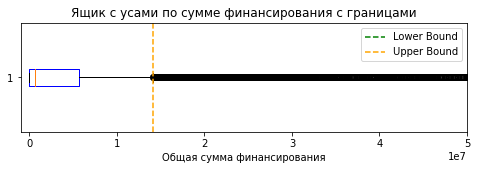

In [27]:
plt.figure(figsize=(8, 2))
ax = plt.gca()

# Построение boxplot
boxprops = dict(color='blue')
flierprops = dict(marker='o', color='red', alpha=0.5)
ax.boxplot(filtred_df['funding_total'], vert=False, flierprops=flierprops, boxprops=boxprops)

# Ограничение по оси X
ax.set_xlim(-1e6, 50e6)

# Границы IQR
desc = filtred_df['funding_total'].describe()
Q1 = desc['25%']
Q3 = desc['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

ax.axvline(lower_bound, color='green', linestyle='--', label='Lower Bound')
ax.axvline(upper_bound, color='orange', linestyle='--', label='Upper Bound')

ax.legend()
plt.title('Ящик с усами по сумме финансирования с границами')
plt.xlabel('Общая сумма финансирования')
plt.show()

Распределение сильно скошено вправо (правосторонний длинный хвост), поэтому среднее (mean) может существенно отличаться от медианы.  
Таким образом для оценки "типичного" размера финансирования лучше использовать медиану и IQR, а не среднее.
Основная масса проектов финансируются в диапазоне примерно от Q1 до Q3.

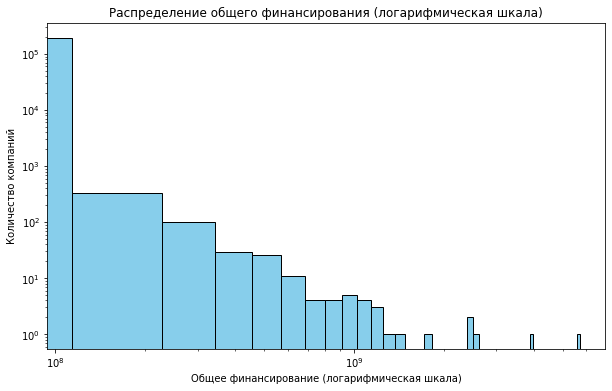

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(companies_df['funding_total'], bins=50, color='skyblue', edgecolor='black', log=True)
plt.xscale('log')  # Логарифмическая шкала по оси X
plt.xlabel('Общее финансирование (логарифмическая шкала)')
plt.ylabel('Количество компаний')
plt.title('Распределение общего финансирования (логарифмическая шкала)')
plt.show() 

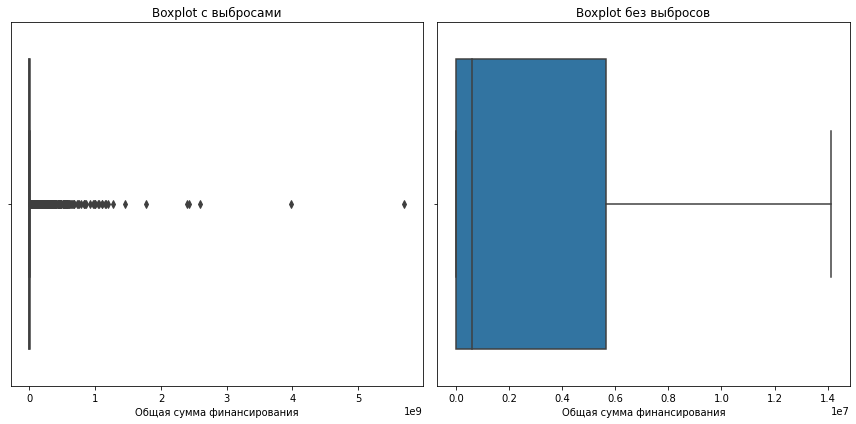

In [29]:
# Построение боксплота с выбросами (по умолчанию)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x=filtred_df['funding_total'])
plt.title('Boxplot с выбросами')
plt.xlabel('Общая сумма финансирования')

# Построение боксплота без выбросов
plt.subplot(1, 2, 2)
sns.boxplot(x=filtred_df['funding_total'], showfliers=False)
plt.title('Boxplot без выбросов')
plt.xlabel('Общая сумма финансирования')

plt.tight_layout()
plt.show()

- В данных много небольших проектов или сделок (сумма финансирования вблизи нуля).
- Есть несколько очень крупных проектов, которые существенно отличаются от остальных (выбросы).
- Для принятия решений можно использовать "без выбросов" график для анализа типичных значений, а "с выбросами" — для оценки экстремальных случаев.


### 3.3. Куплены забесплатно?


In [30]:
# Объединяем компании с данными о покупке
df_merge = companies_df.merge(
    acquisition_df[['acquired_company_id', 'price_amount']],
    left_on='company_ID',
    right_on='acquired_company_id',
    how='left'
)

# Фильтруем компании с нужными условиями
free_acquired_companies = df_merge[
    (df_merge['status'] == 'acquired') &
    (df_merge['price_amount']< 2) &
    (df_merge['funding_total'] != 0)
]

print(f"Количество компаний купленных бесплатно: {free_acquired_companies.shape[0]}")

# Проверка дубликатов
duplicates = free_acquired_companies[free_acquired_companies.duplicated(subset='company_ID', keep=False)]
print(f"Количество дубликатов по company_ID: {duplicates.shape[0]}")
print(duplicates[['company_ID', 'price_amount', 'funding_total']].head(10))

# Удаляем дубликаты, оставляя первую запись
free_acquired_companies_unique = free_acquired_companies.drop_duplicates(subset='company_ID', keep='first')
print(f"После удаления дубликатов осталось компаний: {free_acquired_companies_unique.shape[0]}")

Количество компаний купленных бесплатно: 1618
Количество дубликатов по company_ID: 49
       company_ID  price_amount  funding_total
4274        130.0           0.0     39007800.0
4275        130.0           0.0     39007800.0
6436     139762.0           0.0     20000000.0
6437     139762.0           0.0     20000000.0
11433    146544.0           0.0       650000.0
11434    146544.0           0.0       650000.0
16619      1535.0           0.0       500000.0
16620      1535.0           0.0       500000.0
36642     17758.0           0.0     18000000.0
36643     17758.0           0.0     18000000.0
После удаления дубликатов осталось компаний: 1593


Покупки компаний за 0 или 1 доллар означают, что эти сделки были совершены по очень низкой цене, зачастую символической. Обычно это происходит в случаях, когда компания передается или продается за минимальную сумму, чтобы формально завершить сделку, например, при поглощении, реорганизации или передаче активов. Несмотря на очень низкую цену, такие сделки могут иметь важное значение для бизнеса, например, для передачи технологий, активов или для закрытия финансовых обязательств.

In [31]:
# Выведем первые 10 строк
print("Топ 10 компаний, проданных за 0 или 1 доллар с ненулевым финансированием:")
print(free_acquired_companies_unique.head(10))

Топ 10 компаний, проданных за 0 или 1 доллар с ненулевым финансированием:
     company_ID             name category_code    status founded_at closed_at  \
66      10054.0          Jumptap        mobile  acquired 2005-01-01       NaT   
170    101312.0         SideTour           web  acquired 2011-06-01       NaT   
177    101340.0       ChoicePass    enterprise  acquired 2011-07-01       NaT   
181     10137.0       Producteev      software  acquired 2008-07-08       NaT   
184     10139.0        TradeCard    enterprise  acquired 1999-01-01       NaT   
247     10179.0        GoodGuide           web  acquired 2007-12-01       NaT   
297     10199.0  Where I've Been        travel  acquired 2007-06-08       NaT   
299     10200.0            Swype      software  acquired 2002-01-01       NaT   
390     10252.0           Mob.ly        mobile  acquired 2007-10-01       NaT   
429     10273.0          Angstro      software  acquired 2007-04-27       NaT   

               domain network_user

In [32]:
funding = filtred_df['funding_total']

# Расчет квартилей
q1 = funding.quantile(0.25)
q3 = funding.quantile(0.75)

# Расчет интерквартильного размаха
iqr = q3 - q1

# Расчет границ по IQR
lower_bound = max(0, q1 - 1.5 * iqr)
upper_bound = q3 + 1.5 * iqr

# Определение долей значений за границами
percentile_lower = (funding < lower_bound).mean()  # Доля значений ниже lower_bound
percentile_upper = (funding > upper_bound).mean()  # Доля значений выше upper_bound

# Вывод результатов
print(f'Нижняя граница выбросов (по IQR): {lower_bound}')
print(f'Доля значений ниже нижней границы: {percentile_lower:.2%}')
print()
print(f'Верхняя граница выбросов (по IQR): {upper_bound}')
print(f'Доля значений выше верхней границы: {percentile_upper:.2%}')

Нижняя граница выбросов (по IQR): 0
Доля значений ниже нижней границы: 0.00%

Верхняя граница выбросов (по IQR): 14126625.0
Доля значений выше верхней границы: 14.38%


Большинство данных находится в диапазоне от 0 до примерно 14 миллионов. Значения выше этого, особенно те, что превышают 14 миллионов, считаются выбросами, что может свидетельствовать о редких, крупных инвестициях или аномальных данных.


### 3.4. Цены стартапов по категориям



Большой разброс + высокие цены — это признаки того, что в категории есть как недорогие стартапы, так и очень дорогие, что говорит о наличии крупных, потенциально прибыльных проектов, и о разнообразии цен.

Анализ по этим двум критериям помогает выделить категории, в которых наиболее вероятен высокий риск и потенциальная награда, что важно для инвестиционной стратегии.

Выбираем категории с минимум 50 стартапами — чтобы исключить статистически нерелевантные данные (например, категория с одним стартапом).
Сортируем по медиане цены и разбросу, чтобы выбрать наиболее привлекательные категории с высокой ценой и большим разбросом.

Категории с наибольшим разбросом цен:
                  min_price     max_price  median_price  count     dif_price
category_code                                                               
enterprise              0.0  2.600000e+12           0.0    412  2.600000e+12
public_relations        0.0  3.900000e+10           0.0    219  3.900000e+10
biotech                 0.0  2.000000e+10    13200000.0    454  2.000000e+10
other                   0.0  1.840000e+10           0.0    315  1.840000e+10
mobile                  0.0  1.250000e+10           0.0    418  1.250000e+10
software                0.0  1.020000e+10           0.0   1455  1.020000e+10
games_video             0.0  1.000000e+10           0.0    344  1.000000e+10
security                0.0  7.680000e+09           0.0    131  7.680000e+09
semiconductor           0.0  6.500000e+09           0.0    154  6.500000e+09
web                     0.0  6.400000e+09           0.0    990  6.400000e+09

Категории с высокими медианными ценам

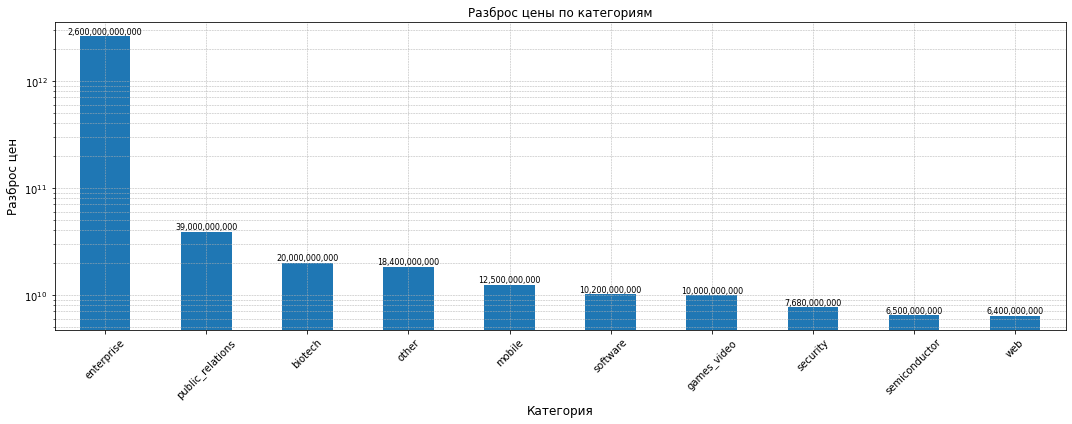

In [33]:
# Группируем по категориям и рассчитываем метрики
grouped = df_merge.groupby('category_code')['price_amount'].agg(['min', 'max', 'median', 'count'])

# Переименование колонок для ясности
grouped.rename(columns={
    'min': 'min_price',
    'max': 'max_price',
    'median': 'median_price',
    'count': 'count'
}, inplace=True)

# Вычисляем разброс цен
grouped['dif_price'] = grouped['max_price'] - grouped['min_price']

# Отбираем категории с достаточной выборкой
min_counts = 50
reliable_groups = grouped[grouped['count'] >= min_counts]

# Сортируем по разбросу цен и медиане
top_spread = reliable_groups.sort_values(by='dif_price', ascending=False).head(10)
top_high_price = reliable_groups.sort_values(by='median_price', ascending=False).head(10)

print("Категории с наибольшим разбросом цен:")
print(top_spread)

print("\nКатегории с высокими медианными ценами:")
print(top_high_price)

# Визуализация
ax = top_spread.plot(kind='bar', y='dif_price', title='Разброс цены по категориям', legend=False, rot=45, figsize=(15, 6))
ax.set_yscale('log')
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Разброс цен', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Добавляем значения
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

- В категориях наблюдается большой разброс цен, что указывает на разнообразие стартапов по стадиям и потенциалу (что важно для инвесторов, ищущих риск и потенциал высокой доходности).
- Большие диапазоны цен создают как возможности для рискованных инвестиций, так и для более стабильных, в зависимости от категории.
- Для принятия решений важно учитывать как медиану, так и разброс цен, чтобы понять уровень риска и потенциала.
- В категориях, таких как мобильные технологии, здравоохранение и биотехнологии, наблюдается широкий диапазон проектов — от небольших до миллиардных.
- Категории вроде полупроводники и нанотехнологии характеризуются высокими медианными ценами, что говорит о большинстве крупных проектов.
- Менее дорогие проекты преобладают в сферах новостей и некоммерческих организаций.
В целом, в некоторых сферах есть большое разнообразие по масштабу проектов, а в других — преобладают крупные инвестиции.


### 3.5. Сколько раундов продержится стартап перед покупкой


In [34]:
# Выполняем группировку по 'status' и считаем среднее по 'funding_rounds'
average_funding_rounds = filtred_df.groupby('status')['funding_rounds'].mean()

print(average_funding_rounds)

status
acquired     0.523526
closed       1.381453
ipo          1.934375
operating    1.522658
Name: funding_rounds, dtype: float64


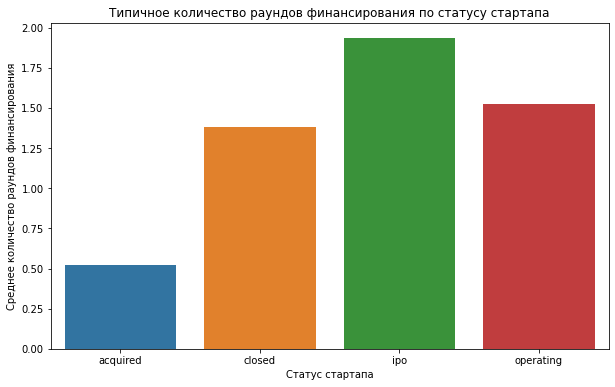

Выводы:
Статус: acquired — среднее количество раундов: 0.52
Статус: closed — среднее количество раундов: 1.38
Статус: ipo — среднее количество раундов: 1.93
Статус: operating — среднее количество раундов: 1.52


In [35]:
# Построим график среднего количества раундов по статусам
average_funding_rounds = filtred_df.groupby('status')['funding_rounds'].mean()

# Визуализация
plt.figure(figsize=(10,6))
sns.barplot(x=average_funding_rounds.index, y=average_funding_rounds.values)
plt.xlabel('Статус стартапа')
plt.ylabel('Среднее количество раундов финансирования')
plt.title('Типичное количество раундов финансирования по статусу стартапа')
plt.show()

# Выводы
print("Выводы:")
for status, mean_rounds in average_funding_rounds.items():
    print(f"Статус: {status} — среднее количество раундов: {mean_rounds:.2f}")

IPO-компании проходят в среднем около 1.93 раундов, что больше, чем у приобретённых (0.52), закрытых (1.38) и работающих (1.52). Это говорит о том, что компании, выходящие на IPO, обычно привлекают больше инвестиций и проходят через больше раундов, что связано с масштабами их развития и необходимостью привлечения значительных средств.


## Шаг 4. Итоговый вывод и рекомендации


#### Проделанная работа:

был подготовлен исследовательский анализ для будущей разработки модели бизнеса, чтобы финансовая компания могла войти на инвестиционный рынок с прицелом на покупку, развитие и последующую перепродажу перспективных стартапов.

#### Решеные задачи:
- решено, по каким столбцам можно объединять данные из разных таблиц исходных данных;
- рассмотрено, почему доверять данным о сотрудниках стартапов и их образовании нет так уж нужно, раз меньшие компании характеризуются большей пропорцией отсутствия данных об образовании сотрудников, что может отражать различия в управлении данными или в структуре кадров;
- найдено, что покупки за 0 или за 1 доллар означают минимальную сумму, чтобы формально завершить сделку, например, при поглощении, реорганизации или передаче активов;
- определили цены в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
- рассчитаны и отображены численные показатели и динамики. 

#### Рекомендации: 

1. Для успешного входа на инвестиционный рынок стартапов рекомендуется сосредоточиться на категориях с высоким потенциалом роста, таких как biotech, software и cleantech, где наблюдается широкий разброс цен и значительные суммы инвестиций. 
2. Важно анализировать стадии финансирования и количество раундов — компании с несколькими раундами или на этапе IPO имеют больший потенциал для перепродажи. 
3. Рекомендуется создавать сбалансированный портфель, сочетая рискованные стартапы с высоким ростом и более зрелые проекты, чтобы максимизировать прибыль и снизить риски. В целом, ключ к успеху — тщательный отбор перспективных компаний и активное управление портфелем.